In [ ]:
import torch
import numpy as np
import random
from collections import deque, defaultdict
import heapq

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─── 地圖與參數 ─────────────────────────────────────────
WIDTH, HEIGHT = 21, 11
treasure_list = [(0,6),(3,16),(8,2),(10,2),(10,17)]
walls_coords  = {
    (0,4),(0,5),(0,7),(0,9),(1,1),(1,2),(1,4),(1,9),(1,10),(1,14),(1,18),
    (2,1),(2,3),(2,5),(2,7),(2,8),(2,9),(2,11),(2,13),(2,15),(2,16),(2,17),(2,19),
    (3,2),(3,8),(3,11),(3,17),(4,1),(4,4),(4,6),(4,10),(4,13),(4,16),(4,17),(4,18),(4,20),
    (5,4),(5,5),(5,6),(5,8),(5,9),(5,14),(5,15),(6,1),(6,2),(6,3),(6,6),(6,8),(6,10),(6,15),(6,16),(6,17),(6,19),
    (7,4),(7,6),(7,8),(7,10),(7,11),(7,17),(7,19),(8,1),(8,4),(8,8),(8,10),(8,13),(8,15),(8,18),(8,19),
    (9,1),(9,2),(9,4),(9,6),(9,7),(9,17),(10,1),(10,4),(10,16),(10,19)
}
START, GOAL = (0,0), (20,10)

# 把 (row, col) 翻成 (x,y) 坐标
treasure_list = [(y, x) for x, y in treasure_list]
walls_coords  = {(y, x) for x, y in walls_coords}

# Q-learning 超參數
MAX_EPISODES = 1000
MAX_STEPS    = 1000
EPSILON, EPS_DECAY, EPS_MIN = 0.9, 0.9995, 0.1
ALPHA, GAMMA = 0.9, 0.995

# Prioritized Sweeping 參數
PLANNING_STEPS     = 5
PRIORITY_THRESHOLD = 1e-4

ACTIONS     = ['up','down','left','right']
NUM_ACTIONS = len(ACTIONS)
NUM_MASK    = 1 << len(treasure_list)
NUM_STATES  = WIDTH * HEIGHT * NUM_MASK

# 在 CUDA 上初始化 Q1, Q2
Q1 = torch.zeros(NUM_STATES, NUM_ACTIONS, device=device)
Q2 = torch.zeros(NUM_STATES, NUM_ACTIONS, device=device)

Model        = {}
predecessors = defaultdict(list)
priority_q   = []

# 禁止回頭用
opposite = {'up':'down','down':'up','left':'right','right':'left'}

def to_index(pos):
    return pos[1] * WIDTH + pos[0]

def encode_state(pos, mask):
    return to_index(pos) * NUM_MASK + mask

def compute_target(pos, act):
    x, y = pos
    if act == 'up':    y = max(0, y-1)
    elif act == 'down':y = min(HEIGHT-1, y+1)
    elif act == 'left':x = max(0, x-1)
    else:               x = min(WIDTH-1, x+1)
    return (x, y)

# 最佳成功路径 & 最多宝藏路径，都要保存 stop_reason
best_steps, best_score, best_path, best_reason = MAX_STEPS+1, -1, None, None
best_treasure_score, best_treasure_path, best_treasure_reason = -1, None, None

epsilon = EPSILON

for ep in range(1, MAX_EPISODES+1):
    pos, mask = START, 0
    s = encode_state(pos, mask)
    path  = [s]
    score = 0
    prev_a = None
    recent = deque(maxlen=10)
    visit_count = defaultdict(int)
    visit_count[s] = 1

    stop_reason = None

    for step in range(1, MAX_STEPS+1):
        # 1) ε-greedy + GPU 屏蔽回頭
        if random.random() < epsilon:
            a = random.randrange(NUM_ACTIONS)
        else:
            qvals = Q1[s] + Q2[s]
            if prev_a is not None:
                back = opposite[ACTIONS[prev_a]]
                bidx = ACTIONS.index(back)
                qvals[bidx] = float('-inf')
            a = int(torch.argmax(qvals).item())

        new_pos = compute_target(pos, ACTIONS[a])
        s2 = encode_state(new_pos, mask)
        if new_pos in walls_coords or new_pos == pos or s2 in recent:
            continue

        # 2) 计算奖励 & 更新 mask
        r = -1
        picked = False
        if new_pos in treasure_list:
            i = treasure_list.index(new_pos)
            if not (mask & (1<<i)):
                mask |= (1<<i)
                r = +10
                score += 1
                picked = True
        elif new_pos == GOAL:
            r = +58 if mask == (NUM_MASK-1) else -50

        if picked:
            prev_a = None

        # 3) Double Q 更新
        s2 = encode_state(new_pos, mask)
        if random.random()<0.5:
            a2 = int(torch.argmax(Q1[s2]).item())
            td = r + GAMMA*Q2[s2,a2] - Q1[s,a]
            Q1[s,a] += ALPHA * td
        else:
            a2 = int(torch.argmax(Q2[s2]).item())
            td = r + GAMMA*Q1[s2,a2] - Q2[s,a]
            Q2[s,a] += ALPHA * td

        # 4) Model & predecessors
        Model[(s,a)] = (r, s2)
        predecessors[s2].append((s,a))

        # 5) push priority
        if abs(td.item()) > PRIORITY_THRESHOLD:
            heapq.heappush(priority_q, (-abs(td.item()), s, a))

        # 6) Prioritized Sweeping
        for _ in range(PLANNING_STEPS):
            if not priority_q: break
            _, sp, ap = heapq.heappop(priority_q)
            rp, sp2 = Model[(sp,ap)]
            if random.random()<0.5:
                anp = int(torch.argmax(Q1[sp2]).item())
                td2 = rp + GAMMA*Q2[sp2,anp] - Q1[sp,ap]
                Q1[sp,ap] += ALPHA * td2
            else:
                anp = int(torch.argmax(Q2[sp2]).item())
                td2 = rp + GAMMA*Q1[sp2,anp] - Q2[sp,ap]
                Q2[sp,ap] += ALPHA * td2

            for spre, apre in predecessors[sp]:
                rpre, spre2 = Model[(spre,apre)]
                q1max = torch.max(Q1[spre2]).item()
                q2max = torch.max(Q2[spre2]).item()
                qtar  = rpre + GAMMA * max(q1max, q2max)
                qpred = max(Q1[spre,apre].item(), Q2[spre,apre].item())
                if abs(qtar - qpred) > PRIORITY_THRESHOLD:
                    heapq.heappush(priority_q, (-abs(qtar-qpred), spre, apre))

        # 7) 真實移動 & 更新狀態
        pos, s = new_pos, s2
        path.append(s2)
        recent.append(s2)
        prev_a = a

        # 如果成功收集完所有宝藏并到达终点
        if pos == GOAL and mask == (NUM_MASK-1):
            stop_reason = "reached goal with all treasures"
            if step < best_steps:
                best_steps, best_score, best_path, best_reason = step, score, path.copy(), stop_reason
            break
        else:
            # 如果 loop 没用 break，自然结束
            stop_reason = "max steps reached"

    # 更新“最多宝藏”轨迹
    if score > best_treasure_score:
        best_treasure_score, best_treasure_path, best_treasure_reason = score, path.copy(), stop_reason

    # ε 衰减
    epsilon = max(EPS_MIN, epsilon*EPS_DECAY)
    if ep % 50 == 0 or ep in (1, MAX_EPISODES):
        print(f"Ep{ep:4d} | ε={epsilon:.3f} | best_steps={best_steps} | best_score={best_score}")

    # 清理 Dyna‐planning 缓存
    Model.clear()
    predecessors.clear()
    priority_q.clear()

# ─── 输出最终结果 ───────────────────────────────────────────
if best_path is not None:
    use_path, label, final_score, final_reason = best_path, "（成功）", best_score, best_reason
else:
    use_path, label, final_score, final_reason = best_treasure_path, "（未成功，以寶藏數最多輸出）", best_treasure_score, best_treasure_reason

# 重播 & 收集宝藏
collected = []
pos, mask = START, 0
for state in use_path:
    idx = state // NUM_MASK
    x = idx % WIDTH
    y = idx // WIDTH
    if (x,y) in treasure_list and (x,y) not in collected:
        collected.append((x,y))
    pos = (x,y)

print(f"=== 最終結果 {label} ===")
print(f"停止原因：{final_reason}")
print(f"步數：{len(use_path)-1}")
print(f"寶藏：{final_score}/{len(treasure_list)} -> {collected}")
print(f"最終停留：{pos} (應為 {GOAL})")

Ep   1 | ε=0.900 | best_steps=1001 | best_score=-1
Ep  50 | ε=0.878 | best_steps=1001 | best_score=-1
Ep 100 | ε=0.856 | best_steps=1001 | best_score=-1
Ep 150 | ε=0.835 | best_steps=1001 | best_score=-1
Ep 200 | ε=0.814 | best_steps=1001 | best_score=-1
Ep 250 | ε=0.794 | best_steps=1001 | best_score=-1
Ep 300 | ε=0.775 | best_steps=1001 | best_score=-1
Ep 350 | ε=0.755 | best_steps=1001 | best_score=-1
Ep 400 | ε=0.737 | best_steps=1001 | best_score=-1
Ep 450 | ε=0.719 | best_steps=1001 | best_score=-1
Ep 500 | ε=0.701 | best_steps=1001 | best_score=-1
Ep 550 | ε=0.684 | best_steps=1001 | best_score=-1
Ep 600 | ε=0.667 | best_steps=1001 | best_score=-1
Ep 650 | ε=0.650 | best_steps=1001 | best_score=-1
Ep 700 | ε=0.634 | best_steps=1001 | best_score=-1
Ep 750 | ε=0.619 | best_steps=1001 | best_score=-1
Ep 800 | ε=0.603 | best_steps=1001 | best_score=-1
Ep 850 | ε=0.588 | best_steps=1001 | best_score=-1
Ep 900 | ε=0.574 | best_steps=1001 | best_score=-1
Ep 950 | ε=0.560 | best_steps=1

In [40]:
coords = []
for s in use_path:
    idx = s // NUM_MASK
    # row ∈ [0, HEIGHT-1], col ∈ [0, WIDTH-1]
    row = idx // WIDTH
    col = idx % WIDTH
    # 恢复成 (x, y) = (col, row)
    coords.append((col, row))

print("完整轨迹：", coords)

完整轨迹： [(0, 0), (1, 0), (0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 7), (2, 7), (2, 8), (3, 8), (3, 9), (3, 10), (2, 10), (3, 10), (3, 9), (3, 8), (3, 7), (2, 7), (2, 8)]


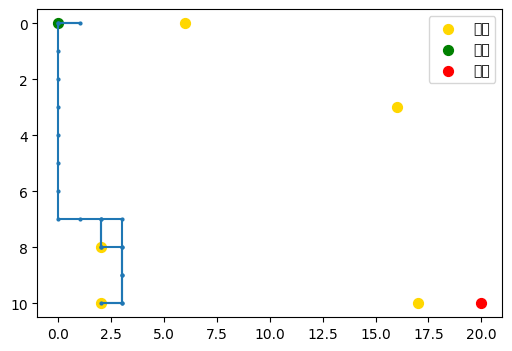

In [41]:
import matplotlib.pyplot as plt

xs, ys = zip(*coords)
plt.figure(figsize=(6,4))
plt.plot(xs, ys, '-o', markersize=2)
# 标注宝藏、起点、终点
tx, ty = zip(*treasure_list)
plt.scatter(tx, ty, c='gold', label='宝藏', s=50)
plt.scatter(START[0], START[1], c='green', label='起点',  s=50)
plt.scatter(GOAL[0],  GOAL[1],  c='red',   label='终点', s=50)
plt.gca().invert_yaxis()  # (0,0) 在左上角
plt.legend()
plt.show()